1.Importing libraries :

In [43]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

2.Load Dataset :

In [44]:
# Import required libraries
df = pd.read_excel("/home/user/workspace/property_price_prediction/datasets/Data_file.xlsx")

3.Dataset Inspection :


In [45]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  int64  
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(4), int64(5), object(1)
memory usage: 1.6+ MB


In [47]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


4. Missing Value Handling :

In [48]:
# Handle missing values
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [49]:
#categorical values
df["ocean_proximity"].unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

In [50]:
#filling missing values
df["total_bedrooms"] = df["total_bedrooms"].fillna(df["total_bedrooms"].median())

In [51]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

5. Exploratory Data Analysis :

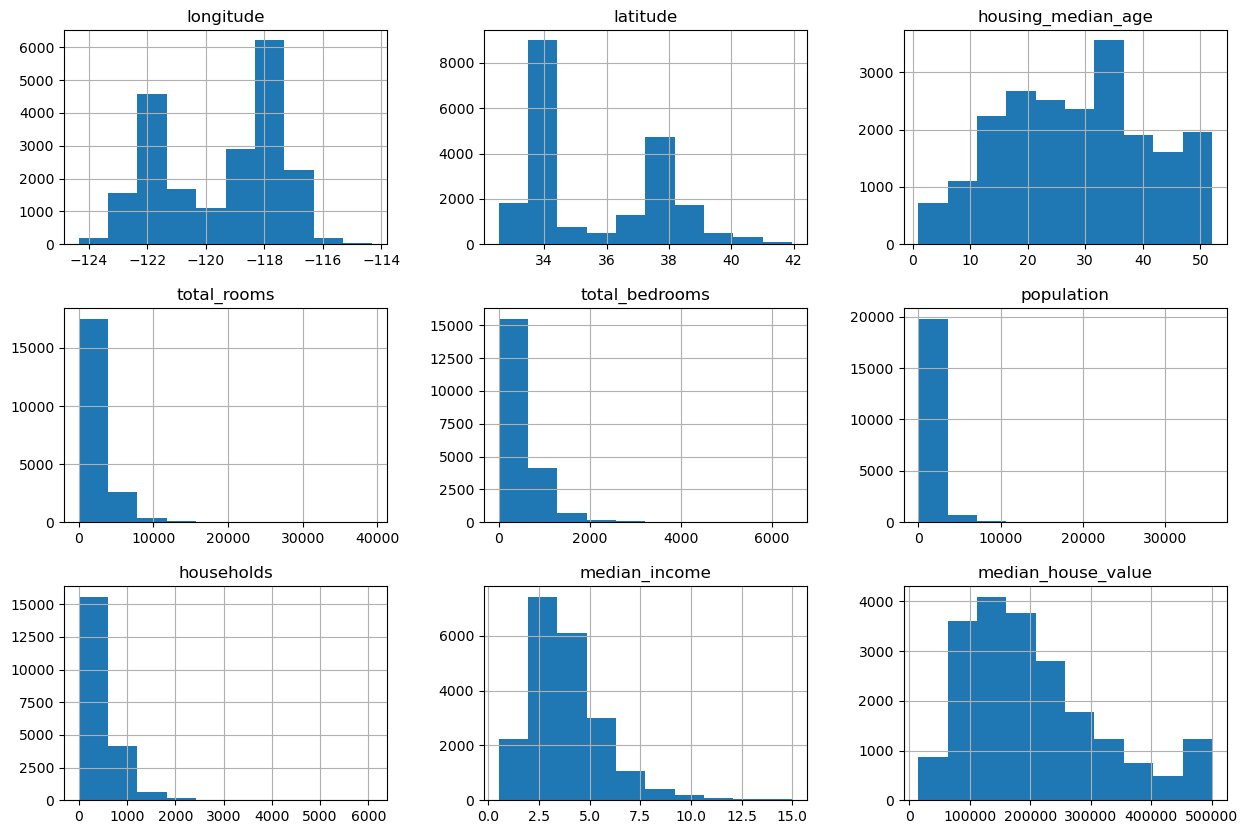

In [52]:
#histogram analysis of each attribute
df.hist(figsize=(15,10))
plt.show()

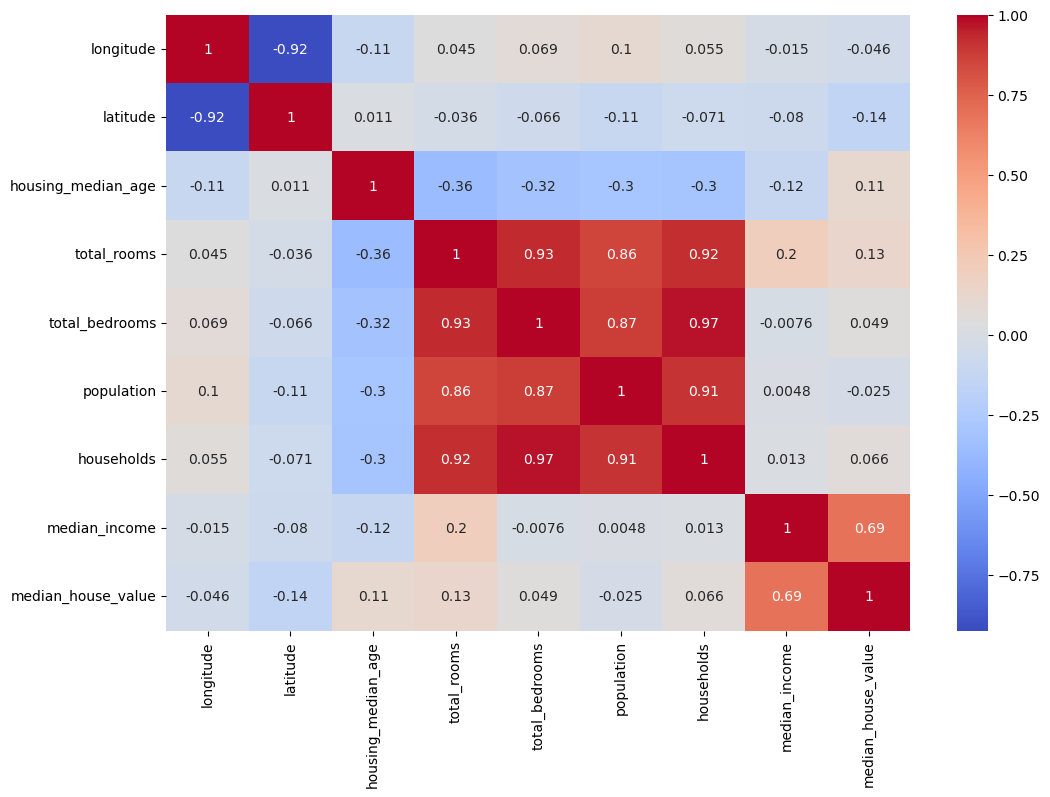

In [53]:
#correlation matrix
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

6.Encoding :

In [54]:
#encoding
df = pd.get_dummies(df, columns=["ocean_proximity"])

In [55]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,False,False,False,True,False
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,False,False,False,True,False
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,False,False,False,True,False
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,False,False,False,True,False
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,False,False,False,True,False


7. Feature & Target Selection :

In [56]:
#feature and target selection
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

8. Train-Test Split

In [57]:
#importing Train test split
from sklearn.model_selection import train_test_split

In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

9.Model selection :

In [59]:
from sklearn.linear_model import LinearRegression

In [60]:
model = LinearRegression()

10.Model Training :

In [61]:
model.fit(X_train, y_train)

LinearRegression()

11.Predictions :

In [62]:
y_pred = model.predict(X_test)

In [63]:
print(y_pred[:10])

[ 54055.44889898 124225.33893718 255489.37949166 268002.43156919
 262769.43481568 139606.3039556  290665.42391416 228264.87637529
 256506.78561005 407923.85843486]


12. Evaluation Metrics :

In [64]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [68]:
#MAE
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 50670.73824097181


In [69]:
#MSE
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 4908476721.156629


In [70]:
#RSME
rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 70060.52184473528


In [71]:
#R2
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.6254240620553597


13.conclusion :

In [72]:
y_pred = model.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 50670.73824097181
MSE: 4908476721.156629
RMSE: 70060.52184473528
R2 Score: 0.6254240620553597


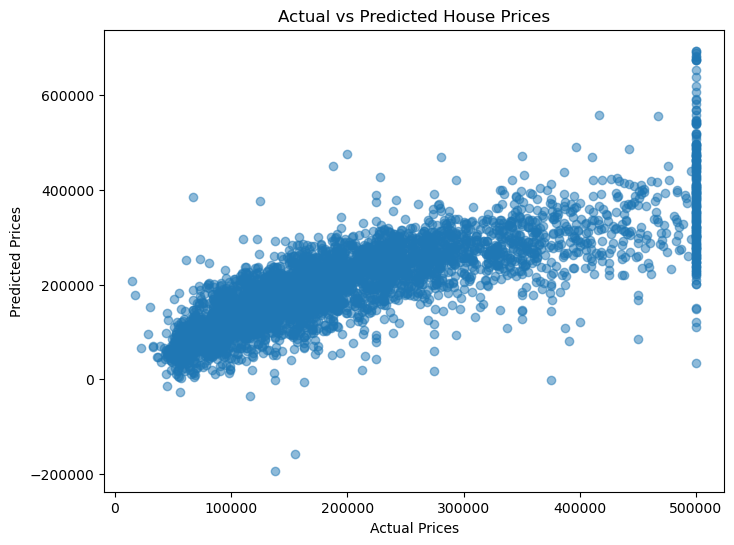

In [75]:
#Final graph
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()

Feature Scaling : It transforms data into similar scale.

In [78]:
#import scaler
from sklearn.preprocessing import StandardScaler

In [79]:
#create scaler
scaler = StandardScaler()

In [80]:
#Scale Training Data
X_train_scaled = scaler.fit_transform(X_train)

In [81]:
#Scale Test Data
X_test_scaled = scaler.transform(X_test)

In [82]:
#Train New Model
scaled_model = LinearRegression()
scaled_model.fit(X_train_scaled, y_train)

LinearRegression()

In [83]:
#prediction 
y_pred_scaled = scaled_model.predict(X_test_scaled)

In [84]:
#evaluation
r2_scaled = r2_score(y_test, y_pred_scaled)
print("Scaled R2 Score:", r2_scaled)

Scaled R2 Score: 0.625339904669574


In [85]:
#Compare Actual vs Predicted Values
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,47700,54055.448899
1,45800,124225.338937
2,500001,255489.379492
3,218600,268002.431569
4,278000,262769.434816
5,158700,139606.303956
6,198200,290665.423914
7,157500,228264.876375
8,340000,256506.785610
9,446600,407923.858435


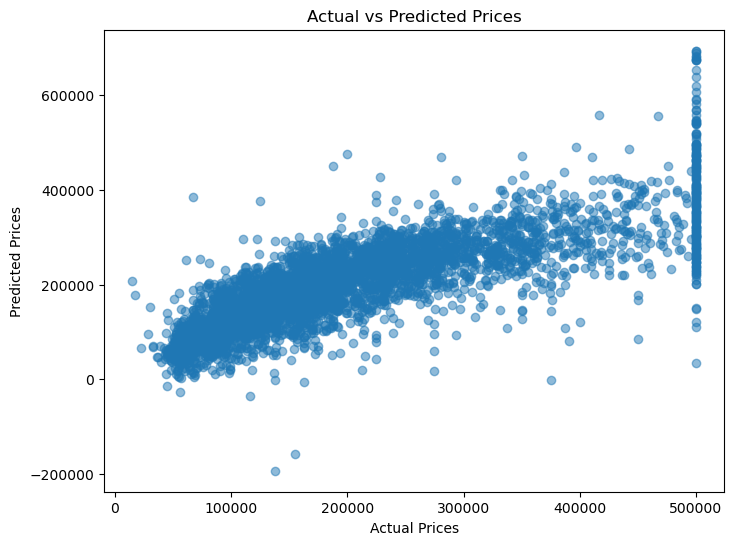

In [86]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()